In [1]:
import os

os.getcwd()

'C:\\Users\\LENOVO\\ironhack\\Week_6\\Week_6_project'

In [2]:
import pandas as pd

In [3]:
demo = pd.read_csv("Data set/df_final_demo.txt")
demo.head()


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [4]:
demo.shape

(70609, 9)

In [5]:
experiment = pd.read_csv("Data set/df_final_experiment_clients.txt")

web_1 = pd.read_csv("Data set/df_final_web_data_pt_1.txt")

web_2 = pd.read_csv("Data set/df_final_web_data_pt_2.txt")

In [6]:
print("Demo:", demo.shape)
print("Experiment:", experiment.shape)
print("Web Part 1:", web_1.shape)
print("Web Part 2:", web_2.shape)

Demo: (70609, 9)
Experiment: (70609, 2)
Web Part 1: (343141, 5)
Web Part 2: (412264, 5)


In [7]:
print("Web Part 1 columns:", web_1.columns.tolist())
print("Web Part 2 columns:", web_2.columns.tolist())

Web Part 1 columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']
Web Part 2 columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']


In [8]:
web = pd.concat(
    [web_1, web_2],
    ignore_index=True
)

In [9]:
web.shape

(755405, 5)

In [10]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [11]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [12]:
experiment["Variation"].value_counts(dropna=False)

Variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

In [13]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [14]:
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


In [15]:
demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [16]:
print("Entire duplicate rows:", demo.duplicated().sum())
print(
    "Duplicated client IDs:",
    demo["client_id"].duplicated().sum()
)

Entire duplicate rows: 0
Duplicated client IDs: 0


In [17]:
demo["gendr"].value_counts(dropna=False)

gendr
U      24122
M      23724
F      22746
NaN       14
X          3
Name: count, dtype: int64

In [18]:
experiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   Variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB


In [19]:
print("Missing values:")
print(experiment.isna().sum())

print("\nEntire duplicate rows:", experiment.duplicated().sum())

print(
    "Duplicated client IDs:",
    experiment["client_id"].duplicated().sum()
)

Missing values:
client_id        0
Variation    20109
dtype: int64

Entire duplicate rows: 0
Duplicated client IDs: 0


In [20]:
web.info()

<class 'pandas.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     755405 non-null  int64
 1   visitor_id    755405 non-null  str  
 2   visit_id      755405 non-null  str  
 3   process_step  755405 non-null  str  
 4   date_time     755405 non-null  str  
dtypes: int64(1), str(4)
memory usage: 28.8 MB


In [21]:
duplicate_rows = web[
    web.duplicated(keep=False)
].sort_values(
    ["client_id", "visitor_id", "visit_id", "date_time"]
)

duplicate_rows.head(20)

,client_id,visitor_id,visit_id,process_step,date_time
631355,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:08
631356,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:08
631353,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:28
631354,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:28
639529,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:29:00
639530,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:29:00
639524,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:18
639525,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:18
639521,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:40
639522,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:40


In [22]:
web_clean = web.drop_duplicates().copy()

In [23]:
print("Rows before:", len(web))
print("Rows after:", len(web_clean))
print("Duplicate rows removed:", len(web) - len(web_clean))
print("Duplicates remaining:", web_clean.duplicated().sum())

Rows before: 755405
Rows after: 744641
Duplicate rows removed: 10764
Duplicates remaining: 0


In [24]:
demo_clean = demo.copy()

In [25]:
missing_demo_rows = demo_clean[
    demo_clean.isna().any(axis=1)
]

print("Rows with at least one missing value:", len(missing_demo_rows))
missing_demo_rows

Rows with at least one missing value: 15


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
missing_demo_rows.isna().sum(axis=1).value_counts().sort_index()

1     1
8    14
Name: count, dtype: int64

In [27]:
demographic_columns = demo_clean.columns.drop("client_id")

demo_clean = demo_clean.dropna(
    subset=demographic_columns,
    how="all"
).copy()

In [28]:
print("Rows removed:", len(demo) - len(demo_clean))

print("\nMissing values remaining:")
print(demo_clean.isna().sum())

Rows removed: 14

Missing values remaining:
client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            1
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64


### 2. Missing Demographic Values

The demographics dataset contained 15 rows with at least one missing value.

Further inspection showed that:

* 14 rows contained a valid `client_id`, but all eight demographic fields were missing.
* One row contained complete client information except for `clnt_age`.

The 14 records without any usable demographic information were removed because there was insufficient information to impute their values reliably.

The client with only a missing `clnt_age` value was retained because all the other client information was complete. The missing age was left as `NaN` rather than replaced with the mean or median, since such imputation would introduce an estimated age that could not be verified.

This client can still be included in the overall A/B test and in analyses that do not depend on age. For age-specific calculations, pandas will generally exclude the missing value automatically.

A separate cleaned DataFrame named `demo_clean` was used so that the original demographics dataset remained unchanged.


In [29]:
print(demo_clean["gendr"].value_counts(dropna=False))
print("\nUnique gender values:", demo_clean["gendr"].unique())

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

Unique gender values: <StringArray>
['U', 'M', 'F', 'X']
Length: 4, dtype: str


### Gender Categories

The `gendr` column was inspected for missing values and inconsistent categories. After removing the 14 records with entirely missing demographic information, no missing gender values remained.

The recorded categories `M`, `F`, `U`, and `X` were retained. Although `U` and `X` are less conventional categories, there was insufficient documentation to classify them as errors or assign them a different meaning. Retaining the original values avoids introducing unsupported assumptions into the analysis.

In [30]:
demo_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
client_id,70595.0,5.005021e+06,2.877269e+06,169.00,2519604.500,5016969.0,7483063.500,9999839.00
clnt_tenure_yr,70595.0,1.205295e+01,6.871819e+00,2.00,6.000,11.0,16.000,62.00
clnt_tenure_mnth,70595.0,1.506594e+02,8.208985e+01,33.00,82.000,136.0,192.000,749.00
clnt_age,70594.0,4.644224e+01,1.559127e+01,13.50,32.500,47.0,59.000,96.00
num_accts,70595.0,2.255528e+00,5.349969e-01,1.00,2.000,2.0,2.000,8.00
bal,70595.0,1.474452e+05,3.015087e+05,13789.42,37346.835,63332.9,137544.905,16320040.15
calls_6_mnth,70595.0,3.382478e+00,2.236580e+00,0.00,1.000,3.0,6.000,7.00
logons_6_mnth,70595.0,5.566740e+00,2.353286e+00,1.00,4.000,5.0,7.000,9.00


### Demographic Data Integrity Checks

Before cleaning the demographic dataset, we check the numerical columns for potentially invalid or inconsistent values.

The checks identify:

- Clients younger than 18 or older than 100
- Negative account balances
- Clients with zero or negative accounts
- Clients whose tenure is greater than their age
- Differences between tenure recorded in years and months

These records are only flagged for further investigation. No data is modified or removed at this stage.


In [31]:
print("Clients younger than 18:",
      (demo_clean["clnt_age"] < 18).sum())

print("Clients older than 100:",
      (demo_clean["clnt_age"] > 100).sum())

print("Negative balances:",
      (demo_clean["bal"] < 0).sum())

print("Zero or negative accounts:",
      (demo_clean["num_accts"] <= 0).sum())

print("Tenure greater than client age:",
      (demo_clean["clnt_tenure_yr"] > demo_clean["clnt_age"]).sum())

print(
    "Inconsistent tenure years and months:",
    (
        demo_clean["clnt_tenure_mnth"] // 12
        != demo_clean["clnt_tenure_yr"]
    ).sum()
)

Clients younger than 18: 374
Clients older than 100: 0
Negative balances: 0
Zero or negative accounts: 0
Tenure greater than client age: 574
Inconsistent tenure years and months: 46


In [32]:
#lets inspect the suspisciuos age and tenure

age_tenure_concerns = demo_clean[
    (demo_clean["clnt_age"] < 18)
    | (demo_clean["clnt_tenure_yr"] > demo_clean["clnt_age"])
].copy()

age_tenure_concerns[
    [
        "client_id",
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth"
    ]
].sort_values(
    ["clnt_age", "clnt_tenure_yr"]
).head(20)

,client_id,clnt_age,clnt_tenure_yr,clnt_tenure_mnth
70216,5417612,13.5,4.0,59.0
67700,6250331,14.0,4.0,59.0
58281,3677152,14.0,22.0,273.0
61687,694216,14.5,2.0,34.0
52768,194675,14.5,4.0,58.0
52964,6366070,14.5,4.0,57.0
55898,6269889,14.5,4.0,58.0
59226,3289678,14.5,4.0,57.0
63086,3329074,14.5,4.0,59.0
65638,7922520,14.5,4.0,58.0


### Investigating Tenure Greater Than Client Age

The initial inspection revealed logically inconsistent records where a client's tenure is greater than their age. A client cannot have maintained an account for longer than they have been alive.

For example, client **3677152** is recorded as being **14 years old**, but has a tenure of **22 years** (`273` months). This means the recorded tenure is **8 years greater than the client's age**, which is not logically possible.

These records will therefore be examined separately and ranked by the difference between tenure and age. This investigation will help determine the severity of the inconsistencies before an appropriate cleaning decision is made.

In [33]:
# Select clients whose tenure is greater than their age
tenure_age_errors = demo_clean[
    demo_clean["clnt_tenure_yr"] > demo_clean["clnt_age"]
].copy()

# Calculate how many years tenure exceeds age
tenure_age_errors["tenure_age_difference"] = (
    tenure_age_errors["clnt_tenure_yr"]
    - tenure_age_errors["clnt_age"]
)

# Display the 20 most severe inconsistencies
tenure_age_errors[
    [
        "client_id",
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "tenure_age_difference"
    ]
].sort_values(
    "tenure_age_difference",
    ascending=False
).head(20)

,client_id,clnt_age,clnt_tenure_yr,clnt_tenure_mnth,tenure_age_difference
40438,3265750,18.0,44.0,532.0,26.0
63062,5951041,24.5,43.0,516.0,18.5
41087,7783003,32.0,49.0,596.0,17.0
7432,6752370,22.0,38.0,464.0,16.0
32834,5618665,39.0,54.0,655.0,15.0
53799,5859904,21.0,35.0,430.0,14.0
35161,5250186,23.5,37.0,449.0,13.5
22168,5430117,42.5,55.0,668.0,12.5
64690,357409,51.0,62.0,749.0,11.0
65366,2917506,37.5,48.0,576.0,10.5


#### Age and Tenure Investigation Results

The investigation confirms that some age and tenure records are logically inconsistent.

The most severe example is client **3265750**, who is recorded as being **18 years old** with **44 years of tenure** (`532` months). The recorded tenure therefore exceeds the client's age by **26 years**.

Another example is client **5951041**, who is recorded as being **24.5 years old** with **43 years of tenure**, producing a difference of **18.5 years**.

These differences cannot be explained by ordinary rounding and indicate data-quality problems in either the age or tenure fields.

Because these demographic inconsistencies do not necessarily make the clients' digital activity invalid, the complete client records will not be deleted. Instead, the affected records will be flagged and excluded when conducting analyses that depend specifically on age or tenure.

In [34]:
# Flag records with an invalid age or tenure relationship
demo_clean["age_tenure_issue"] = (
    (demo_clean["clnt_age"] < 18)
    | (demo_clean["clnt_age"] > 100)
    | (demo_clean["clnt_tenure_yr"] > demo_clean["clnt_age"])
)

# Count the flag values
demo_clean["age_tenure_issue"].value_counts()

age_tenure_issue
False    69720
True       875
Name: count, dtype: int64

### Handling Suspicious Demographic Values
 Although some age and tenure values are logically inconsistent, the affected clients may still have valid experiment assignments and digital-process activity.

Therefore, the original client records will be preserved. A separate demographic analysis copy will be created, and an `age_tenure_issue` column will be added to flag suspicious records.

The flag is interpreted as follows:

- **`True`** means that the record has at least one age or tenure concern, such as:
  - The client is younger than 18.
  - The client is older than 100.
  - The recorded tenure is greater than the client's age.
  - The tenure recorded in years is inconsistent with the tenure recorded in months.

- **`False`** means that the record passed all the age and tenure quality checks and can be used more confidently in demographic analysis.

The flag allows suspicious demographic records to be excluded from age- or tenure-specific analysis without deleting the client or removing potentially valid A/B testing activity.

No corrected values will be invented because the available data does not indicate whether the client's age, tenure, or both were recorded incorrectly.

In [35]:

# Create a separate copy for demographic analysis
demo_analysis = demo_clean.copy()

# Identify missing or invalid ages
invalid_age = (
    demo_analysis["clnt_age"].isna()
    | (demo_analysis["clnt_age"] < 18)
    | (demo_analysis["clnt_age"] > 100)
)

# Identify impossible age-tenure relationships
invalid_age_tenure = (
    demo_analysis["clnt_tenure_yr"]
    > demo_analysis["clnt_age"]
)

# Identify inconsistent tenure-year and tenure-month records
invalid_tenure_conversion = (
    demo_analysis["clnt_tenure_mnth"] // 12
    != demo_analysis["clnt_tenure_yr"]
)

# Flag every record with an age or tenure concern
demo_analysis["age_tenure_issue"] = (
    invalid_age
    | invalid_age_tenure
    | invalid_tenure_conversion
)

# Display the corrected flag results
print("Age and tenure flag counts:")
print(demo_analysis["age_tenure_issue"].value_counts())

print("\nAge and tenure flag percentages:")
print(
    demo_analysis["age_tenure_issue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Age and tenure flag counts:
age_tenure_issue
False    69675
True       920
Name: count, dtype: int64

Age and tenure flag percentages:
age_tenure_issue
False    98.7
True      1.3
Name: proportion, dtype: float64


#### Age–Tenure Quality Flag Results

The age and tenure quality assessment evaluated all **70,595 client records**.

- **69,676 records (98.7%)** received a `False` flag. This means they passed all the defined age and tenure quality checks.
- **920 records (1.3%)** received a `True` flag. This means they contain at least one suspicious age or tenure condition.

A `True` result does not necessarily mean that every demographic value in the record is incorrect. It means that at least one of the following conditions was detected:

- The client's age is below 18 or above 100.
- The client's tenure is greater than their age.
- Tenure recorded in years is inconsistent with tenure recorded in months.

The pandas output includes the following labels:

- `age_tenure_issue` is the name of the column being summarised.
- `Name: count` indicates that `.value_counts()` returned the number of records belonging to each flag.
- `Name: proportion` indicates that `normalize=True` initially calculated proportions. These proportions were then multiplied by `100` using `.mul(100)` to display percentages.
- `dtype: int64` means the count results are stored as whole integers.
- `dtype: float64` means the percentage results are stored as decimal numbers.

The two flag counts add up to the complete dataset:

**69,675+ 920 = 70,595 records**

Because the flagged records represent only **1.3%** of the demographic dataset, they can be excluded from analyses requiring reliable age and tenure information without deleting the clients from the main A/B testing dataset. Their experiment assignments and digital activity may still be valid.

In [36]:
# Display the number of records with and without concerns
print("Age and tenure flag results:")
print(demo_analysis["age_tenure_issue"].value_counts())

# Display the percentage represented by each flag
print("\nAge and tenure flag percentages:")
print(
    demo_analysis["age_tenure_issue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Age and tenure flag results:
age_tenure_issue
False    69675
True       920
Name: count, dtype: int64

Age and tenure flag percentages:
age_tenure_issue
False    98.7
True      1.3
Name: proportion, dtype: float64


### Cleaning and Standardising the Gender Column

The `gendr` column contains five observed values: `M`, `F`, `U`, `X`, and missing values (`NaN`).

A new column named `gendr_clean` will be created so that the original `gendr` values remain available for reference.

The categories will be standardised as follows:

- `M` becomes `Male`.
- `F` becomes `Female`.
- `U` becomes `Unknown`.
- `X` becomes `Unspecified (X)`.
- Missing values (`NaN`) become `Missing`.

`Unknown` represents records explicitly coded as `U` in the original dataset.

`Unspecified (X)` preserves the original `X` code because its precise meaning is not defined in the available dataset information. It will not be assumed to represent male, female, or unknown.

`Missing` means that no gender value was recorded for the client. It is different from `Unknown`, which was an actual value in the original data.

Creating `gendr_clean` instead of replacing `gendr` preserves the raw category values and provides clearer labels for demographic analysis. No clients are deleted during this process.

In [37]:
# Create a cleaned gender column while preserving the original column
demo_analysis["gendr_clean"] = demo_analysis["gendr"].replace(
    {
        "M": "Male",
        "F": "Female",
        "U": "Unknown",
        "X": "Unspecified (X)"
    }
)

# Label missing gender values explicitly
demo_analysis["gendr_clean"] = (
    demo_analysis["gendr_clean"].fillna("Missing")
)

# Display the cleaned gender counts
print("Cleaned gender counts:")
print(demo_analysis["gendr_clean"].value_counts())

# Display the cleaned gender percentages
print("\nCleaned gender percentages:")
print(
    demo_analysis["gendr_clean"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Cleaned gender counts:
gendr_clean
Unknown            24122
Male               23724
Female             22746
Unspecified (X)        3
Name: count, dtype: int64

Cleaned gender percentages:
gendr_clean
Unknown            34.17
Male               33.61
Female             32.22
Unspecified (X)     0.00
Name: proportion, dtype: float64


#### Gender Cleaning Results

The cleaned gender column contains all **70,595 client records**.

The resulting distribution is:

- **Unknown:** 24,122 clients (34.17%)
- **Male:** 23,724 clients (33.61%)
- **Female:** 22,746 clients (32.22%)
- **Unspecified (X):** 3 clients (approximately 0.004%)

A `Missing` category does not appear in the output because no missing gender values remain in `demo_analysis`. The missing demographic records identified earlier were handled during a previous cleaning step.

The three `Unspecified (X)` records appear as `0.00%` in the pandas output because the percentages were rounded to two decimal places. Their actual percentage is approximately 0.004%, so `0.00%` should not be interpreted as zero records.

The pandas output labels mean:

- `gendr_clean` is the name of the column being summarised.
- `Name: count` indicates that the first output contains record counts.
- `Name: proportion` indicates that the second output was calculated from proportions and converted into percentages.
- `dtype: int64` means the counts are stored as whole integers.
- `dtype: float64` means the percentages are stored as decimal numbers.

The cleaned labels are now suitable for demographic analysis, while the original `gendr` column remains unchanged for reference.

In [38]:
print("Negative account counts:",
      (demo_analysis["num_accts"] < 0).sum())

print("Negative balances:",
      (demo_analysis["bal"] < 0).sum())

print("Negative calls:",
      (demo_analysis["calls_6_mnth"] < 0).sum())

print("Negative logons:",
      (demo_analysis["logons_6_mnth"] < 0).sum())

Negative account counts: 0
Negative balances: 0
Negative calls: 0
Negative logons: 0


#### Remaining Numerical Validity Results

The remaining numerical demographic columns were checked for negative values.

The results show:

- Negative account counts: **0**
- Negative balances: **0**
- Negative calls: **0**
- Negative logons: **0**

No logically invalid negative values were found. Therefore, no records need to be changed or removed based on these checks.

Large positive values will not automatically be treated as errors because high balances, account counts, calls, or logons may represent genuine client behaviour.

In [39]:
# Check remaining missing values in the working demographic DataFrame
print("Remaining missing values:")
print(demo_analysis.isna().sum())

Remaining missing values:
client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            1
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
age_tenure_issue    0
gendr_clean         0
dtype: int64


#### Final Demographic Validation Results

The final demographic dataset, `demo_analysis`, contains **70,595 client records and 11 columns**.

The 11 columns consist of the original demographic variables plus two additional analysis columns:

- `age_tenure_issue`: identifies records with a missing, invalid, or inconsistent age or tenure value.
- `gendr_clean`: contains standardised and clearly labelled gender categories.

The final validation confirmed:

- **Entire duplicate rows:** 0
- **Duplicated client IDs:** 0

This means every row is unique and each client appears only once in the demographic dataset.

The final age–tenure flag distribution is:

- **False:** 69,675 records
- **True:** 920 records

A `False` flag means the record passed the defined age and tenure checks. A `True` flag means the record contains at least one age or tenure concern. These flagged clients remain in the dataset but will be excluded from analyses requiring reliable age or tenure information.

The cleaned gender distribution is:

- **Unknown:** 24,122 clients
- **Male:** 23,724 clients
- **Female:** 22,746 clients
- **Unspecified (X):** 3 clients

`Unknown` represents records originally coded as `U`, while `Unspecified (X)` preserves the three original `X` values without assigning them an unsupported meaning.

Based on these results, the demographic cleaning and validation are complete. The `demo_analysis` DataFrame is ready for demographic analysis and later integration with the experiment and digital-process data.

### Final Demographic Data Validation

A final validation is performed to confirm that the demographic working DataFrame is ready for analysis.

The validation checks:

- The final number of rows and columns
- Entirely duplicated rows
- Duplicated client IDs
- The distribution of the age–tenure quality flag
- The distribution of the cleaned gender categories

A duplicated row means that every value in one record is identical to another record.

A duplicated client ID means that the same client appears more than once. Because the demographic dataset is expected to contain one record per client, duplicate client IDs would require further investigation.

This step only validates `demo_analysis`; it does not delete or modify any records.

In [40]:
# Display the final DataFrame size
print("Final demographic shape:", demo_analysis.shape)

# Check for complete duplicate rows
print(
    "Entire duplicate rows:",
    demo_analysis.duplicated().sum()
)

# Check for duplicated client IDs
print(
    "Duplicated client IDs:",
    demo_analysis["client_id"].duplicated().sum()
)

# Display the final age-tenure flag counts
print("\nAge and tenure flag counts:")
print(demo_analysis["age_tenure_issue"].value_counts())

# Display the final cleaned gender counts
print("\nCleaned gender counts:")
print(demo_analysis["gendr_clean"].value_counts())

Final demographic shape: (70595, 11)
Entire duplicate rows: 0
Duplicated client IDs: 0

Age and tenure flag counts:
age_tenure_issue
False    69675
True       920
Name: count, dtype: int64

Cleaned gender counts:
gendr_clean
Unknown            24122
Male               23724
Female             22746
Unspecified (X)        3
Name: count, dtype: int64


## Cleaning the Experiment Assignment Data

The `experiment` DataFrame contains information about each client's participation in the Vanguard A/B test.

It has two columns:

- `client_id`: uniquely identifies each client.
- `Variation`: identifies which version of the digital process the client received.

The expected `Variation` categories are:

- `Control`: the client used Vanguard's original digital process.
- `Test`: the client used the redesigned digital process.
- `NaN`: the client has no recorded experiment assignment.

The `Variation` column is the main grouping variable for the A/B test because it allows the performance of the original process to be compared with the redesigned process.

Before cleaning, the column will be inspected for category counts, missing values and unexpected labels. This inspection does not modify or remove any records.

In [41]:
# Display all Variation categories, including missing values
print("Variation category counts:")
print(
    experiment["Variation"].value_counts(dropna=False)
)

# Count the missing experiment assignments
print(
    "\nMissing Variation values:",
    experiment["Variation"].isna().sum()
)

# Display the unique non-missing category labels
print(
    "\nUnique non-missing Variation categories:"
)
print(experiment["Variation"].dropna().unique())

Variation category counts:
Variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

Missing Variation values: 20109

Unique non-missing Variation categories:
<StringArray>
['Test', 'Control']
Length: 2, dtype: str


### Reviewing the Experiment Groups

The `experiment` dataset contains **70,609 clients**. The `Variation` column shows which version of Vanguard's digital process each client received.

The results show:

- **26,968 clients** were assigned to the `Test` group and used the redesigned process.
- **23,532 clients** were assigned to the `Control` group and used the original process.
- **20,109 clients** have a missing experiment assignment (`NaN`).

Altogether, **50,500 clients** participated in the experiment:

**26,968 Test clients + 23,532 Control clients = 50,500 assigned clients**

The label check found only `Test` and `Control`. This means the recorded labels are consistent and do not contain spelling mistakes, unexpected categories, or capitalisation problems.

Some additional pandas information appears in the output:

- `Name: count` means the displayed values are the number of clients in each group.
- `dtype: int64` means the counts are stored as whole numbers.
- `StringArray` means the group labels are stored as text.
- `Length: 2` confirms that only two non-missing groups were found.
- `dtype: str` also indicates that `Test` and `Control` are text values.

The `Test` and `Control` labels therefore do not need to be corrected. However, the **20,109 unassigned clients** cannot be included in the A/B comparison because we do not know which version of the process they received.

The next step is to create a separate analysis DataFrame containing the **50,500 assigned clients**, while keeping the original `experiment` dataset unchanged.

### Creating the Experiment Analysis DataFrame

The A/B test can only compare clients who were assigned to either the `Test` or `Control` group.

The **20,109 clients** with a missing `Variation` value cannot be included because we do not know which version of the digital process they received.

A new DataFrame named `experiment_analysis` will therefore be created with:

- **26,968 Test clients**
- **23,532 Control clients**
- **50,500 assigned clients in total**

The original `experiment` DataFrame will remain unchanged and will still contain all 70,609 records. We are creating a filtered copy, not permanently deleting the unassigned clients.

In [42]:
# Create a copy containing only Test and Control clients
experiment_analysis = experiment[
    experiment["Variation"].isin(["Test", "Control"])
].copy()

# Display the size of the analysis-ready DataFrame
print(
    "Experiment analysis shape:",
    experiment_analysis.shape
)

# Display the final Test and Control counts
print("\nExperiment group counts:")
print(
    experiment_analysis["Variation"].value_counts()
)

# Confirm that no missing assignments remain
print(
    "\nMissing Variation values:",
    experiment_analysis["Variation"].isna().sum()
)

# Confirm that each client appears only once
print(
    "Duplicated client IDs:",
    experiment_analysis["client_id"].duplicated().sum()
)

Experiment analysis shape: (50500, 2)

Experiment group counts:
Variation
Test       26968
Control    23532
Name: count, dtype: int64

Missing Variation values: 0
Duplicated client IDs: 0


### Can Every Client Be Confidently Assigned to a Single Experimental Group?

Yes. Experimental group assignment was validated at the `client_id` level because the client is the participant in the A/B test.

After removing records with missing `Variation` values, the experiment dataset contained **50,500 clients**:

- **Test:** 26,968 clients
- **Control:** 23,532 clients

The `Variation` column contained only the two expected labels: `Test` and `Control`. There were no missing group assignments remaining and no duplicated `client_id` values.

Because every `client_id` appears only once in the cleaned experiment dataset, each participating client is associated with exactly one experimental group. No client is simultaneously assigned to both Test and Control.

This confirms that the client-level experimental assignments are internally consistent and can be used reliably for the A/B test.

#### Experiment Cleaning Complete

The validation confirms that `experiment_analysis` contains **50,500 uniquely assigned clients**, with no missing `Variation` values and no duplicated client IDs.

This DataFrame is ready to be merged with the cleaned demographic and web-activity data.

## Reviewing the Combined Web-Activity Data

The `web` DataFrame combines the two original web-activity files. Each row represents one action taken by a client during Vanguard's digital process.

The main columns are:

- `client_id`: identifies the client.
- `visitor_id`: identifies the website visitor.
- `visit_id`: identifies a particular website visit or session.
- `process_step`: records the step reached during the process.
- `date_time`: records when the event occurred.

A duplicated `client_id` is expected because one client can complete several steps or make several visits. Therefore, repeated client IDs must not automatically be deleted.

However, a complete duplicate occurs when every column in two or more rows is identical. These duplicate event records may count the same action more than once and could distort completion, time and error calculations.

Before cleaning, we will check the DataFrame size, missing values, complete duplicates, process-step labels and the data type of `date_time`.

### Duplicate Web Events

The combined `web` DataFrame contained **10,764 completely duplicated event rows**. These duplicates were removed to prevent the same client actions from being counted more than once.

The cleaned DataFrame, `web_clean`, now contains **744,641 rows** with **no remaining complete duplicates**.

Repeated client IDs were retained because a client can perform multiple actions or make several visits.

In [43]:
# Check missing values
print("Missing values:")
print(web_clean.isna().sum())

# Review the process-step categories
print("\nProcess-step categories:")
print(
    web_clean["process_step"].value_counts(dropna=False)
)

# Check how the date_time column is stored
print("\ndate_time data type:")
print(web_clean["date_time"].dtype)

Missing values:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Process-step categories:
process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

date_time data type:
str


### Process Steps and Timestamp Format

The `process_step` column contains the five expected stages of Vanguard's digital process:

- `start`: 234,999 events
- `step_1`: 162,797 events
- `step_2`: 132,750 events
- `step_3`: 111,589 events
- `confirm`: 102,506 events

No missing or unexpected process-step labels were found.

The number of event records decreases from `start` to `confirm`. However, these raw counts should not yet be interpreted as client drop-off rates because one client can repeat a step or complete multiple visits. Completion rates will be calculated later using the appropriate client or visit level.

The `date_time` column currently has the data type `str`, meaning that its values are stored as text. Text timestamps cannot be reliably used for calculating time differences or sorting events chronologically.

The column must therefore be converted to pandas' datetime format.

In [44]:
# Review the process-step categories
print("Process-step categories:")
print(
    web_clean["process_step"].value_counts(dropna=False)
)

# Check how the date_time column is stored
print("\ndate_time data type:")
print(web_clean["date_time"].dtype)

Process-step categories:
process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

date_time data type:
str


### Timestamp Conversion Result

The `date_time` column was successfully converted from text to pandas datetime format.

- `datetime64[us]` means the timestamps are stored as date-and-time values with microsecond precision.
- `Invalid timestamps after conversion: 0` confirms that every timestamp was converted successfully.
- No values were changed to `NaT` (`Not a Time`).

The timestamps can now be used to arrange events chronologically and calculate the time clients spent moving through the digital process.

In [45]:
# Convert date_time from text to pandas datetime format
web_clean["date_time"] = pd.to_datetime(
    web_clean["date_time"],
    errors="coerce"
)

# Confirm the new data type
print("Updated date_time data type:")
print(web_clean["date_time"].dtype)

# Check whether any timestamps failed to convert
print(
    "Invalid timestamps after conversion:",
    web_clean["date_time"].isna().sum()
)

Updated date_time data type:
datetime64[us]
Invalid timestamps after conversion: 0


### Arranging Web Events in Chronological Order

Each row in `web_clean` represents one action within a client's digital journey. To analyse movement through the process, the events must appear in the order in which they occurred.

The data will be sorted by:

1. `client_id` — groups events belonging to the same client.
2. `visit_id` — groups events from the same website visit.
3. `date_time` — arranges the events from earliest to latest within each visit.

Sorting does not remove or change any event information. It only changes the order in which the rows appear.

After sorting, the index will be reset so that the row numbers run continuously from `0`.

In [46]:
# Sort events chronologically within each client visit
web_clean = web_clean.sort_values(
    by=["client_id", "visit_id", "date_time"]
).reset_index(drop=True)

# Display the first 10 sorted events
web_clean[
    [
        "client_id",
        "visitor_id",
        "visit_id",
        "process_step",
        "date_time"
    ]
].head(10)

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
5,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55
6,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43
7,546,475037402_89828530214,731811517_9330176838_94847,start,2017-06-17 10:03:29
8,546,475037402_89828530214,731811517_9330176838_94847,step_1,2017-06-17 10:03:39
9,546,475037402_89828530214,731811517_9330176838_94847,step_2,2017-06-17 10:03:52


### Final Web-Data Validation

The cleaned web-activity DataFrame, `web_clean`, contains **744,641 event records and 5 columns**.

The final validation confirms:

- **Complete duplicate rows:** 0
- **Total missing values:** 0
- **Timestamp format:** `datetime64[us]`
- **Process-step categories:** 5

The five valid process steps are:

`start → step_1 → step_2 → step_3 → confirm`

`datetime64[us]` means the timestamps are stored as date-and-time values with microsecond precision.

The events have also been arranged chronologically within each client visit. Therefore, `web_clean` is ready to be connected with the cleaned experiment and demographic data.

### Suitability of the Cleaned Web Data

The cleaned web-event dataset remains suitable for analysis. Complete duplicate rows were removed, timestamps were converted successfully, no missing values remain, and all process-step labels are valid.

The identifier checks showed that some `visit_id` values are associated with multiple clients, including visits involving clients from both experimental groups. Therefore, `visit_id` is not treated as a globally unique identifier.

Client-level A/B test measures are calculated using `client_id`, while visit-level duration, sequence and error analyses use the combination of `client_id` and `visit_id`. With this identifier strategy, the dataset can be used reliably while the shared visit IDs are documented as a possible tracking limitation.

# Display the final cleaned web-data shape
print("Final web_clean shape:", web_clean.shape)

# Confirm that no complete duplicates remain
print(
    "Remaining complete duplicates:",
    web_clean.duplicated().sum()
)

# Confirm that no missing values remain
print(
    "Total missing values:",
    web_clean.isna().sum().sum()
)

# Confirm the timestamp data type
print(
    "date_time data type:",
    web_clean["date_time"].dtype
)

# Confirm the number of process-step categories
print(
    "Number of process-step categories:",
    web_clean["process_step"].nunique()
)

# Display the process-step labels
print(
    "Process-step labels:",
    web_clean["process_step"].unique().tolist()
)

## Merging Experiment Assignments with Demographics

The cleaned experiment and demographic DataFrames share the `client_id` column.

The merge will connect each Test or Control client with their demographic information:

- `experiment_analysis` provides the client's `Variation` assignment.
- `demo_analysis` provides age, tenure, gender, accounts, balance, calls and logons.

A left merge will be used so that all **50,500 experiment participants** are preserved. Demographic information will be added wherever the same `client_id` exists in `demo_analysis`.

The merge is expected to be one-to-one because each client appears only once in both DataFrames.

The merge indicator will show:

- `both`: the client was found in both DataFrames.
- `left_only`: the experiment client was not found in the demographic data.
- `right_only`: a demographic client existed without a matching experiment client. This category will not appear in a left merge because `experiment_analysis` is the left DataFrame.

In [48]:
# Merge experiment assignments with demographic information
client_analysis = experiment_analysis.merge(
    demo_analysis,
    on="client_id",
    how="left",
    validate="one_to_one",
    indicator=True
)

# Display the merged DataFrame size
print("Client analysis shape:", client_analysis.shape)

# Check whether experiment clients matched demographic records
print("\nMerge results:")
print(client_analysis["_merge"].value_counts())

# Count clients without matching demographic information
print(
    "\nExperiment clients without demographics:",
    (client_analysis["_merge"] == "left_only").sum()
)

Client analysis shape: (50500, 13)

Merge results:
_merge
both          50488
left_only        12
right_only        0
Name: count, dtype: int64

Experiment clients without demographics: 12


### Experiment and Demographic Merge Results

The merge preserved all **50,500 experiment participants**.

- **50,488 clients** were found in both `experiment_analysis` and `demo_analysis`.
- **12 clients** have a valid Test or Control assignment but no matching demographic record.

A new Boolean column named `demographics_available` was created:

- `True` means that the client has matching demographic information.
- `False` means that the client has no matching demographic information.

The 12 clients marked `False` were not deleted because they may still have valid experiment assignments and web activity.

The flag will be used differently depending on the analysis:

- The main A/B performance analysis can include all 50,500 clients because it depends primarily on `Variation` and web activity.
- Demographic comparisons will use only clients where `demographics_available == True`.
- Analyses involving age or tenure will require both `demographics_available == True` and `age_tenure_issue == False`.

For example, the reliable demographic subset can be created with:

`client_analysis[client_analysis["demographics_available"] == True]`

The final `client_analysis` DataFrame contains **50,500 rows and 13 columns**. Each row represents one experiment participant, and no participant was lost during the merge.

In [49]:
# Create a flag showing whether demographics are available
client_analysis["demographics_available"] = (
    client_analysis["_merge"] == "both"
)

# Remove the temporary merge-indicator column
client_analysis = client_analysis.drop(columns="_merge")

# Confirm the flag results
print("Demographics availability:")
print(
    client_analysis["demographics_available"].value_counts()
)

print("\nUpdated client_analysis shape:")
print(client_analysis.shape)


Demographics availability:
demographics_available
True     50488
False       12
Name: count, dtype: int64

Updated client_analysis shape:
(50500, 13)


In [50]:
event_analysis = web_clean.merge(
    client_analysis,
    on="client_id",
    how="inner",
    validate="many_to_one"
)

print("Event analysis shape:", event_analysis.shape)
print("Unique experiment clients:", event_analysis["client_id"].nunique())

print("\nVariation counts:")
print(event_analysis["Variation"].value_counts(dropna=False))

print("\nMissing values:")
print(event_analysis.isna().sum())

Event analysis shape: (317235, 17)
Unique experiment clients: 50500

Variation counts:
Variation
Test       176699
Control    140536
Name: count, dtype: int64

Missing values:
client_id                   0
visitor_id                  0
visit_id                    0
process_step                0
date_time                   0
Variation                   0
clnt_tenure_yr            100
clnt_tenure_mnth          100
clnt_age                  112
gendr                     100
num_accts                 100
bal                       100
calls_6_mnth              100
logons_6_mnth             100
age_tenure_issue          100
gendr_clean               100
demographics_available      0
dtype: int64


In [51]:
print("Events without demographic records:")
print(
    event_analysis["demographics_available"]
    .value_counts(dropna=False)
)

print("\nEvents with demographics but missing age:")
print(
    event_analysis[
        (event_analysis["demographics_available"] == True)
        & (event_analysis["clnt_age"].isna())
    ][["client_id", "visit_id", "process_step", "clnt_age"]]
)

Events without demographic records:
demographics_available
True     317135
False       100
Name: count, dtype: int64

Events with demographics but missing age:
        client_id                      visit_id process_step  clnt_age
146508    4666211  193475184_47241294073_678330        start       NaN
146509    4666211  193475184_47241294073_678330       step_1       NaN
146510    4666211  193475184_47241294073_678330       step_2       NaN
146511    4666211  193475184_47241294073_678330       step_3       NaN
146512    4666211  193475184_47241294073_678330        start       NaN
146513    4666211  193475184_47241294073_678330        start       NaN
146514    4666211  740801132_41889378563_243921        start       NaN
146515    4666211  740801132_41889378563_243921        start       NaN
146516    4666211  740801132_41889378563_243921       step_1       NaN
146517    4666211  740801132_41889378563_243921       step_2       NaN
146518    4666211  740801132_41889378563_243921       step_

### Missing Demographic Information After the Event Merge

The merged event-level dataset contains 317,235 website events from all 50,500 experiment clients.

A total of 100 event rows have missing demographic information. These events belong to the 12 experiment clients for whom no corresponding demographic record was available. Their web activity and experiment-group assignment remain valid, so these events are retained for process and A/B test analysis.

The `clnt_age` column contains 112 missing values. This includes the 100 events without demographic records and additional events linked to the previously identified client whose demographic record exists but whose age is missing.

Therefore, demographic missing values will only affect analyses that require those particular demographic variables. They will not prevent the events from being used to calculate completion rates, process times or error rates.

## Preparing the Event Sequence

The web events must be arranged chronologically so that each client's movement through the online process can be analysed correctly.

Events are sorted by `client_id`, `visit_id`, and `date_time`. This places each client's actions in the order in which they occurred during each visit.

A numerical order is also assigned to the process steps:

- `start` = 0
- `step_1` = 1
- `step_2` = 2
- `step_3` = 3
- `confirm` = 4

This numerical mapping will later help identify successful completions, backward movements, repeated steps and possible process errors.
    

In [52]:
# Define the expected order of the online process
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

# Add the numerical step position
event_analysis["step_number"] = (
    event_analysis["process_step"]
    .map(step_order)
)

# Sort the events into chronological order within each visit
event_analysis = (
    event_analysis
    .sort_values(
        by=["client_id", "visit_id", "date_time"]
    )
    .reset_index(drop=True)
)

print("Missing step numbers:", event_analysis["step_number"].isna().sum())

print("\nStep-number mapping:")
print(
    event_analysis[
        ["process_step", "step_number"]
    ]
    .drop_duplicates()
    .sort_values("step_number")
)

event_analysis[
    [
        "client_id",
        "visit_id",
        "date_time",
        "process_step",
        "step_number",
        "Variation"
    ]
].head(15)

Missing step numbers: 0

Step-number mapping:
  process_step  step_number
0        start            0
1       step_1            1
2       step_2            2
3       step_3            3
4      confirm            4


,client_id,visit_id,date_time,process_step,step_number,Variation
0,555,637149525_38041617439_716659,2017-04-15 12:57:56,start,0,Test
1,555,637149525_38041617439_716659,2017-04-15 12:58:03,step_1,1,Test
2,555,637149525_38041617439_716659,2017-04-15 12:58:35,step_2,2,Test
3,555,637149525_38041617439_716659,2017-04-15 13:00:14,step_3,3,Test
4,555,637149525_38041617439_716659,2017-04-15 13:00:34,confirm,4,Test
5,647,40369564_40101682850_311847,2017-04-12 15:41:28,start,0,Test
6,647,40369564_40101682850_311847,2017-04-12 15:41:35,step_1,1,Test
7,647,40369564_40101682850_311847,2017-04-12 15:41:53,step_2,2,Test
8,647,40369564_40101682850_311847,2017-04-12 15:45:02,step_3,3,Test
9,647,40369564_40101682850_311847,2017-04-12 15:47:45,confirm,4,Test


## Creating a Visit-Level Dataset

The `event_analysis` dataset contains one row for every website action. Since a single visit can contain several actions, the data is grouped by `client_id`, `visit_id`, and `Variation` to create one summary row per visit.

For each visit, we calculate:

- the time of the first recorded event;
- the time of the last recorded event;
- the total number of recorded events;
- the highest process step reached;
- whether the visit reached the `confirm` step.

A visit is marked as completed when at least one `confirm` event appears during that visit. This visit-level dataset will be used to analyse completion rates and process duration.

In [53]:
visit_summary = (
    event_analysis
    .groupby(
        ["client_id", "visit_id", "Variation"],
        as_index=False
    )
    .agg(
        visit_start=("date_time", "min"),
        visit_end=("date_time", "max"),
        event_count=("process_step", "size"),
        highest_step=("step_number", "max"),
        completed=(
            "process_step",
            lambda steps: (steps == "confirm").any()
        )
    )
)

# Calculate the recorded duration of each visit
visit_summary["duration_seconds"] = (
    visit_summary["visit_end"]
    - visit_summary["visit_start"]
).dt.total_seconds()

print("Visit summary shape:", visit_summary.shape)
print("Unique clients:", visit_summary["client_id"].nunique())
print("Unique visits:", visit_summary["visit_id"].nunique())

print("\nCompletion status:")
print(visit_summary["completed"].value_counts(dropna=False))

print("\nVisits by experimental group:")
print(visit_summary["Variation"].value_counts())

visit_summary.head()

Visit summary shape: (69447, 9)
Unique clients: 50500
Unique visits: 69205

Completion status:
completed
True     37879
False    31568
Name: count, dtype: int64

Visits by experimental group:
Variation
Test       37204
Control    32243
Name: count, dtype: int64


,client_id,visit_id,Variation,visit_start,visit_end,event_count,highest_step,completed,duration_seconds
0,555,637149525_38041617439_716659,Test,2017-04-15 12:57:56,2017-04-15 13:00:34,5,4,True,158.0
1,647,40369564_40101682850_311847,Test,2017-04-12 15:41:28,2017-04-12 15:47:45,5,4,True,377.0
2,934,7076463_57954418406_971348,Test,2017-04-18 02:36:30,2017-04-18 02:38:52,4,0,False,142.0
3,1028,557292053_87239438319_391157,Control,2017-04-08 18:51:28,2017-04-08 19:00:26,9,3,False,538.0
4,1104,543158812_46395476577_767725,Control,2017-06-12 07:49:18,2017-06-12 07:49:18,1,0,False,0.0


### Completion-Rate Results

The Control group contained 23,532 clients, of whom 15,434 reached the final `confirm` step. This produced a completion rate of **65.59%**.

The Test group contained 26,968 clients, of whom 18,687 reached the final `confirm` step. This produced a completion rate of **69.29%**.

The Test group's completion rate was therefore **3.70 percentage points higher** than that of the Control group:

\[
69.29\% - 65.59\% = 3.70 \text{ percentage points}
\]

Relative to the Control group's completion rate, this represents an improvement of approximately **5.64%**.

These descriptive results suggest that clients using the new Test design were more likely to complete the online process. However, a hypothesis test is still required to determine whether the observed difference is statistically significant or could reasonably have occurred by chance.


In [54]:
# Create one summary row per client
client_kpi = (
    visit_summary
    .groupby(
        ["client_id", "Variation"],
        as_index=False
    )
    .agg(
        number_of_visits=("visit_id", "nunique"),
        completed=("completed", "any")
    )
)

# Calculate completion results by group
completion_summary = (
    client_kpi
    .groupby("Variation")
    .agg(
        total_clients=("client_id", "nunique"),
        completed_clients=("completed", "sum"),
        completion_rate=("completed", "mean")
    )
)

# Convert the completion rate from a proportion to a percentage
completion_summary["completion_rate"] = (
    completion_summary["completion_rate"]
    .mul(100)
    .round(2)
)

print("Client KPI shape:", client_kpi.shape)

print("\nCompletion summary:")
display(completion_summary)

Client KPI shape: (50500, 4)

Completion summary:


,total_clients,completed_clients,completion_rate
Variation,,,
Control,23532,15434,65.59
Test,26968,18687,69.29


## Visualising Completion Rates

A bar chart is used to compare the percentage of clients who reached the `confirm` step in the Test and Control groups.

The chart displays the completion rate for each experimental group, with the exact percentage shown above each bar. This makes the observed difference of 3.70 percentage points easier to interpret visually.

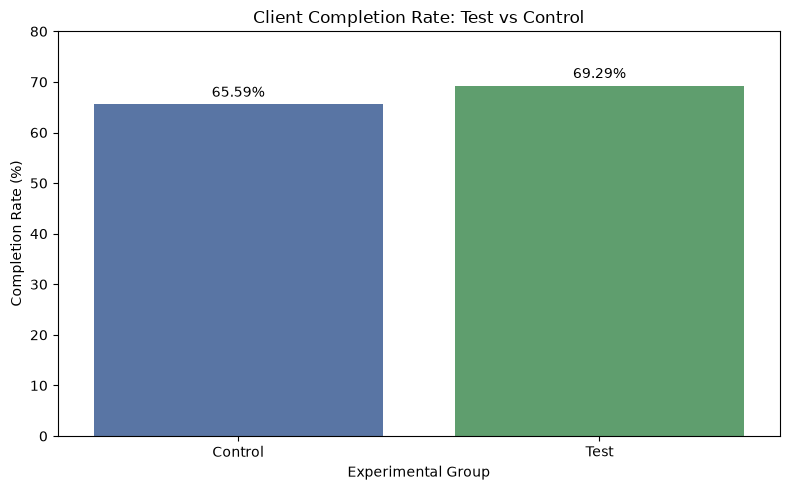

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare completion rates for plotting
completion_plot = (
    completion_summary
    .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=completion_plot,
    x="Variation",
    y="completion_rate",
    hue="Variation",
    palette={
        "Control": "#4C72B0",
        "Test": "#55A868"
    },
    legend=False
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Client Completion Rate: Test vs Control")
plt.xlabel("Experimental Group")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 80)

plt.tight_layout()
plt.show()

### Interpretation of the Completion-Rate Bar Chart

The bar chart compares the percentage of clients who completed the online process in the Control and Test groups.

The **Control group**, which used the existing digital design, achieved a completion rate of **65.59%**. The **Test group**, which used the new design, achieved a higher completion rate of **69.29%**.

This represents an absolute increase of:

\[
69.29\% - 65.59\% = 3.70 \text{ percentage points}
\]

The taller Test bar provides visual evidence that clients using the new design were more likely to reach the final `confirm` step.

However, this chart only describes the observed difference. A statistical hypothesis test is still required to determine whether the difference is statistically significant and unlikely to be explained by random variation.

In [56]:
import numpy as np
from scipy.stats import norm

# Completion counts
test_completed = client_kpi.loc[
    client_kpi["Variation"] == "Test",
    "completed"
].sum()

control_completed = client_kpi.loc[
    client_kpi["Variation"] == "Control",
    "completed"
].sum()

# Total clients
test_total = client_kpi.loc[
    client_kpi["Variation"] == "Test",
    "client_id"
].nunique()

control_total = client_kpi.loc[
    client_kpi["Variation"] == "Control",
    "client_id"
].nunique()

# Completion proportions
test_proportion = test_completed / test_total
control_proportion = control_completed / control_total

# Pooled completion proportion
pooled_proportion = (
    (test_completed + control_completed)
    / (test_total + control_total)
)

# Standard error
standard_error = np.sqrt(
    pooled_proportion
    * (1 - pooled_proportion)
    * ((1 / test_total) + (1 / control_total))
)

# Z-statistic
z_statistic = (
    test_proportion - control_proportion
) / standard_error

# One-sided p-value: Test completion rate > Control completion rate
p_value = norm.sf(z_statistic)

alpha = 0.05

print("Test completion rate:", round(test_proportion * 100, 2), "%")
print("Control completion rate:", round(control_proportion * 100, 2), "%")
print("Z-statistic:", round(z_statistic, 4))
print("P-value:", p_value)

if p_value < alpha:
    print(
        "Decision: Reject the null hypothesis. "
        "The Test completion rate is significantly higher "
        "than the Control completion rate."
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis. "
        "There is insufficient evidence that the Test "
        "completion rate is higher."
    )

Test completion rate: 69.29 %
Control completion rate: 65.59 %
Z-statistic: 8.8745
P-value: 3.511966623790716e-19
Decision: Reject the null hypothesis. The Test completion rate is significantly higher than the Control completion rate.


## Hypothesis Test: Completion Rate

### Business question

Did clients using the new **Test interface** complete the online process at a higher rate than clients using the existing **Control interface**?

### Statistical test used

A **two-proportion z-test** was used to compare the completion rates of the Test and Control groups.

This test was selected because:

1. The outcome is binary: each client either completed the process or did not complete it.

2. We are comparing completion proportions between two independent groups:
   the Test group and the Control group.

3. Both groups contain sufficiently large numbers of clients for the normal approximation.

   This means the Test and Control groups have enough clients for their completion proportions to behave approximately like a normal distribution. Therefore, the two-proportion z-test can reliably compare the completion rates of the two groups.

   This refers to the sampling distribution of the completion proportions, not the individual completion values. Each individual client's outcome remains binary: completed or not completed.

### Hypotheses

- **Null hypothesis (H₀):** The Test completion rate is not higher than the Control completion rate.

  **H₀: p_test ≤ p_control**

- **Alternative hypothesis (H₁):** The Test completion rate is higher than the Control completion rate.

  **H₁: p_test > p_control**

Here, `p_test` represents the true completion proportion for the Test interface, while `p_control` represents the true completion proportion for the Control interface.

### Significance level

The significance level is:

**α = 0.05**

This means that we accept a maximum 5% risk of rejecting the null hypothesis when it is actually true. Such an incorrect rejection is known as a **Type I error**.

### Results

- Control clients: 23,532
- Control clients who completed the process: 15,434
- Control completion rate: **65.59%**
- Test clients: 26,968
- Test clients who completed the process: 18,687
- Test completion rate: **69.29%**
- Observed difference: **3.70 percentage points**
- Z-statistic: **8.8745**
- P-value: **3.51 × 10⁻¹⁹**

The Test completion rate was calculated as:

**18,687 ÷ 26,968 × 100 = 69.29%**

The Control completion rate was calculated as:

**15,434 ÷ 23,532 × 100 = 65.59%**

The difference between the groups was:

**69.29% − 65.59% = 3.70 percentage points**

### Decision rule

- If the p-value is less than 0.05, reject H₀.
- If the p-value is greater than or equal to 0.05, fail to reject H₀.

### Statistical decision

The p-value is:

**3.51 × 10⁻¹⁹**

This is much smaller than the significance level:

**3.51 × 10⁻¹⁹ < 0.05**

Therefore, we **reject the null hypothesis**.

### Reason for the decision

If there were genuinely no improvement in the Test interface's completion rate, obtaining a difference at least this strong would be extraordinarily unlikely.

The very small p-value indicates that the observed difference is unlikely to be explained by random sampling variation alone.

The positive z-statistic also supports the direction of the result: the Test completion rate is higher than the Control completion rate.

###  Business interpretation

There is very strong statistical evidence that the new Test interface produces a higher completion rate than the existing Control interface.

Clients using the Test interface completed the process at a rate of **69.29%**, compared with **65.59%** for the Control interface. This represents an improvement of **3.70 percentage points**.

Therefore, the new interface appears to help more clients reach the confirmation stage. However, statistical significance alone does not determine whether the improvement is large enough to justify full implementation. The business should also consider the practical effect, implementation cost, error rate, and time spent completing the process.


# The Data set Identifiers

The data set has three identifiers. These are;

**client_id → visitor_id → visit_id**

Based on their expected meanings, this is the proposed identifier hierarchy.
Each `visit_id` can contain multiple process-step event records.

This hierarchy has not yet been confirmed and will be tested using the actual
data.

In [57]:
import pandas as pd

In [58]:
identifier_summary = pd.DataFrame({
    "total_rows": [
        len(web_clean),
        len(web_clean),
        len(web_clean)
    ],
    "unique_values": [
        web_clean["client_id"].nunique(),
        web_clean["visitor_id"].nunique(),
        web_clean["visit_id"].nunique()
    ],
    "missing_values": [
        web_clean["client_id"].isna().sum(),
        web_clean["visitor_id"].isna().sum(),
        web_clean["visit_id"].isna().sum()
    ]
}, index=["client_id", "visitor_id", "visit_id"])

identifier_summary

,total_rows,unique_values,missing_values
client_id,744641,120157,0
visitor_id,744641,130236,0
visit_id,744641,158095,0


### Initial identifier findings

The cleaned web-event dataset contains 744,641 event records.

The identifier analysis found:

- 120,157 unique `client_id` values
- 130,236 unique `visitor_id` values
- 158,095 unique `visit_id` values
- No missing values in any of the three identifier columns

There are more visitor IDs than client IDs, which suggests that some clients
may be associated with more than one digital visitor identity.

There are also more visit IDs than visitor IDs, which suggests that some
visitors may have participated in more than one visit.

The dataset contains approximately 4.71 event records per visit on average,
showing that an individual visit can contain several recorded process steps.

These counts are consistent with the proposed hierarchy, but they do not prove
that it is respected. Additional checks are required to determine whether one
visitor ID is connected to multiple clients or whether one visit ID is
connected to multiple visitors or clients.

In [59]:
clients_per_visitor = (
    web_clean.groupby("visitor_id")["client_id"]
    .nunique()
)

visitors_per_visit = (
    web_clean.groupby("visit_id")["visitor_id"]
    .nunique()
)

clients_per_visit = (
    web_clean.groupby("visit_id")["client_id"]
    .nunique()
)

print(
    "Visitor IDs connected to multiple clients:",
    (clients_per_visitor > 1).sum()
)

print(
    "Visit IDs connected to multiple visitors:",
    (visitors_per_visit > 1).sum()
)

print(
    "Visit IDs connected to multiple clients:",
    (clients_per_visit > 1).sum()
)

Visitor IDs connected to multiple clients: 1645
Visit IDs connected to multiple visitors: 0
Visit IDs connected to multiple clients: 1012


### Identifier-hierarchy verification results

The expected hierarchy was only partially respected.

The analysis found:

- 1,645 visitor IDs connected to more than one client
- 0 visit IDs connected to more than one visitor
- 1,012 visit IDs connected to more than one client

Every `visit_id` was associated with only one `visitor_id`. This confirms a
consistent relationship between visits and digital visitors.

However, some visitor IDs were associated with multiple clients, and some
visit IDs contained events associated with multiple clients. Therefore,
`visitor_id` cannot always be treated as a unique customer identifier, and
`visit_id` cannot always be assumed to represent the journey of only one
client.

These relationships may represent shared browsers or devices, account
switching, reused technical identifiers, or tracking inconsistencies. The
available data do not yet establish which explanation is correct.

The hierarchy is therefore partially, but not completely, respected.
Additional investigation is required before choosing the final unit of analysis
for client-specific journey reconstruction.

In [60]:
multi_client_visit_ids = clients_per_visit[
    clients_per_visit > 1
].index

multi_client_visit_examples = (
    web_clean[
        web_clean["visit_id"].isin(multi_client_visit_ids)
    ]
    .sort_values(["visit_id", "date_time"])
)

multi_client_visit_examples[
    [
        "client_id",
        "visitor_id",
        "visit_id",
        "process_step",
        "date_time"
    ]
].head(30)

,client_id,visitor_id,visit_id,process_step,date_time
651419,8737837,490189976_95584517144,100952948_77681780860_858472,start,2017-05-24 12:23:19
651420,8737837,490189976_95584517144,100952948_77681780860_858472,step_1,2017-05-24 12:23:32
651421,8737837,490189976_95584517144,100952948_77681780860_858472,start,2017-05-24 12:26:39
651422,8737837,490189976_95584517144,100952948_77681780860_858472,step_1,2017-05-24 12:26:43
651423,8737837,490189976_95584517144,100952948_77681780860_858472,start,2017-05-24 12:29:22
651424,8737837,490189976_95584517144,100952948_77681780860_858472,step_1,2017-05-24 12:29:29
651425,8737837,490189976_95584517144,100952948_77681780860_858472,step_2,2017-05-24 12:30:20
651426,8737837,490189976_95584517144,100952948_77681780860_858472,step_3,2017-05-24 12:31:20
651427,8737837,490189976_95584517144,100952948_77681780860_858472,confirm,2017-05-24 12:31:49
21620,288350,490189976_95584517144,100952948_77681780860_858472,start,2017-05-24 12:32:54


### Examination of multi-client visits

The displayed examples confirm that some `visit_id` values contain events from
more than one client.

For example, visit `100952948_77681780860_858472` was associated with one
visitor ID but contained events from clients `8737837` and `288350`. Both
clients generated their own process-step sequences within the same recorded
visit.

This means that `visit_id` consistently identifies a technical visit associated
with one visitor, but it does not always identify the journey of only one
client.

Using `visit_id` alone for client-specific journey reconstruction could mix
events from different clients. A combination of `client_id` and `visit_id`
provides a more precise client-session grouping.

However, some clients appear before and after another client's activity within
the same visit. Consequently, calculating duration from the first to the last
event may include time during which another client was active.

Multi-client visits should therefore be flagged and treated carefully in
session-duration analysis. A main time analysis based on single-client visits
would avoid mixing activity from different clients, while the excluded visits
should be documented.

In [61]:
experiment_visit_structure = (
    event_analysis
    .groupby("visit_id")
    .agg(
        client_count=("client_id", "nunique"),
        variation_count=("Variation", "nunique")
    )
)

print(
    "Experiment visits:",
    len(experiment_visit_structure)
)

print(
    "Experiment visits containing multiple clients:",
    (experiment_visit_structure["client_count"] > 1).sum()
)

print(
    "Visits containing both Test and Control clients:",
    (experiment_visit_structure["variation_count"] > 1).sum()
)

Experiment visits: 69205
Experiment visits containing multiple clients: 242
Visits containing both Test and Control clients: 120


### Multi-client visits within the experiment

The experimental event data contained 69,205 unique visits.

Of these:

- 242 visits contained multiple experiment clients
- 120 visits contained clients from both the Test and Control groups

Multi-client visits represented approximately 0.35% of experiment visits, and
mixed Test-Control visits represented approximately 0.17% of all experiment
visits.

A visit containing clients from both experimental groups cannot be assigned
entirely to either Test or Control. Doing so would mix activity from clients
who experienced different interfaces.

This does not invalidate the client-level completion-rate analysis because
completion and experiment assignment were measured using `client_id`. Each
client retained their own group assignment and was counted only once.

However, the mixed-group visits are ambiguous for visit-level analysis,
including journey reconstruction and total visit duration. They should not be
treated as ordinary single-group visits in the primary session-level analysis.